In [8]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
import matplotlib.style

matplotlib.style.use("ggplot")

In [10]:
import nltk

nltk.download(["punkt"])

[nltk_data] Downloading package punkt to /home/fahmi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Raw Corpus

In [11]:
df_corpus = pd.read_json(f"../data/corpus.jsonl", lines=True)
print(df_corpus.shape)

df_corpus.head()

(1499, 6)


,id,title,content,published_at,word_count,source_url
0,1bcfc529-9788-4f8b-a8e4-c2780922cb9e,Wakil Dubes Walanda Gumbira Ningali Holland In...,bogor hotél institut (bhi) gawé bareng jeung f...,2009-11-16,231,http://majalah-balebat.blogspot.com/2009/11/wa...
1,7ad64ffc-449a-4218-b3fb-a9ad92925068,Warga Bogor Mapag Taun anyar Islam,bogor - datang ton anyar islam 1431-hijréh pap...,2009-12-19,265,http://majalah-balebat.blogspot.com/2009/12/wa...
2,6c714fec-c629-4604-bfac-0096e1a0f624,Warugan Lemah: Pola Lembur Urang Sunda Buhun,naskah warugan lemah kandelna ngan tilu lempir...,2011-06-12,1255,http://majalah-balebat.blogspot.com/2011/06/wa...
3,5669e653-63ab-49b4-be39-7bf07f2eefe7,Manfaat Olahraga Pikeun Kasehatan,anu ku urang tos terang olahraga teh penting p...,2018-11-28,246,http://tipscaras.blogspot.com/2017/02/contoh-a...
4,bfc35e44-876f-4ddd-a7c3-dbe6339a27f1,DINA JANDÉLA INDUNG,"méméh layung kubur panineungan dina jandéla, g...",2023-07-24,69,https://basasunda.com/puisi-bahasa-sunda


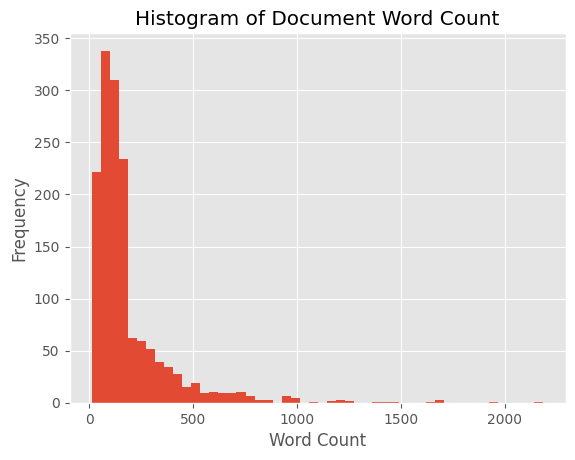

In [12]:
fig, ax = plt.subplots()

df_corpus["word_count"].hist(bins=50, ax=ax)
ax.set_title("Histogram of Document Word Count")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")

plt.show()

## Triplet

In [14]:
df_triplet = pd.read_json("../data/dataset-new/cleaned/triplet.jsonl", lines=True)
print(df_triplet.shape)

df_triplet.head()

(7959, 3)


,query,positive,negative
0,Naon tujuan Holland Indonésé Festival?,Festival anu buka wakil duta besar walanda keu...,Urang walanda pohara resep ku masak urang indo...
1,Kapan Holland Indonésé Festival dilaksanakeun?,"Festival ieu dilaksanakeun di hotél salak, jal...",Sagalana rupa budaya milik bangsa indonésé dih...
2,Saha nu nyarios ngeunaan hubungan indonésé jeu...,"Wakil duta besar walanda, annemieke ruigrok ka...",Nurutkeun r. ay. suni wijogawati laku wakil pu...
3,Ala naon anu dipidangkeun di festival budaya ieu?,Sagalana rupa budaya milik bangsa indonésé dih...,Kuring gumbira aya di indonésé nu jalma saromé...
4,Saha anu mendakan cara sieun batik tulis?,Ruigrok sempet nengetan pengrajin batik mrakté...,Festival budaya ieu ngan gel sapoé.


In [ ]:
df_triplet["query_chars"] = df_triplet["query"].str.len()
df_triplet["positive_chars"] = df_triplet["positive"].str.len()
df_triplet["negative_chars"] = df_triplet["negative"].str.len()

df_triplet.describe()

,query_chars,positive_chars,negative_chars
count,7959.000000,7959.000000,7959.000000
mean,37.704109,93.246262,78.138711
std,9.087441,36.004896,28.494178
min,13.000000,13.000000,0.000000
25%,31.000000,68.000000,58.000000
50%,37.000000,90.000000,75.000000
75%,43.000000,113.000000,94.000000
max,74.000000,462.000000,238.000000


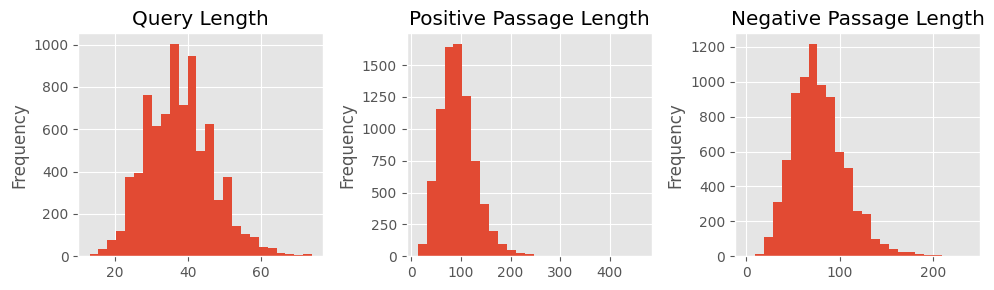

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

df_triplet["query_chars"].plot.hist(bins=25, ax=ax[0])
ax[0].set_title("Query Length")

df_triplet["positive_chars"].plot.hist(bins=25, ax=ax[1])
ax[1].set_title("Positive Passage Length")

df_triplet["negative_chars"].plot.hist(bins=25, ax=ax[2])
ax[2].set_title("Negative Passage Length")

fig.tight_layout()
plt.show()

## BEIR

In [15]:
df_beir_corpus = pd.read_json("../data/dataset-new/cleaned/corpus.jsonl", lines=True)
print(df_beir_corpus.shape)

df_beir_corpus.head()

(1499, 3)


,_id,title,text
0,1bcfc529-9788-4f8b-a8e4-c2780922cb9e,Wakil Dubes Walanda Gumbira Ningali Holland In...,bogor hotél institut (bhi) gawé bareng jeung f...
1,7ad64ffc-449a-4218-b3fb-a9ad92925068,Warga Bogor Mapag Taun anyar Islam,bogor - datang ton anyar islam 1431-hijréh pap...
2,6c714fec-c629-4604-bfac-0096e1a0f624,Warugan Lemah: Pola Lembur Urang Sunda Buhun,naskah warugan lemah kandelna ngan tilu lempir...
3,5669e653-63ab-49b4-be39-7bf07f2eefe7,Manfaat Olahraga Pikeun Kasehatan,anu ku urang tos terang olahraga teh penting p...
4,bfc35e44-876f-4ddd-a7c3-dbe6339a27f1,DINA JANDÉLA INDUNG,"méméh layung kubur panineungan dina jandéla, g..."


In [16]:
df_beir_queries = pd.read_json("../data/dataset-new/cleaned/queries.jsonl", lines=True)
print(df_beir_queries.shape)

df_beir_queries.head()

(11612, 2)


,_id,text
0,99b78da2-54b4-4afa-b4c8-06df0dfb53d8,Holland Indonésé Festival di Bogor
1,42a37e80-e810-4813-a551-09dcbd471fa6,apa tujuan festival budaya di Bogor
2,5a0b9395-c28a-4c33-b5cc-5c502ee78790,siapa wakil duta besar Walanda
3,b821e85d-a6c3-4413-a0ba-d09ab1b72c2a,hubungan antara Indonésé jeung Walanda
4,37959229-85cc-432d-97e4-b437002efb17,acara naon anu dipidangkeun di festival


In [17]:
df_beir_queries["text"].str.len().describe()

count    11612.000000
mean        35.708319
std         10.217947
min          7.000000
25%         29.000000
50%         35.000000
75%         42.250000
max         79.000000
Name: text, dtype: float64

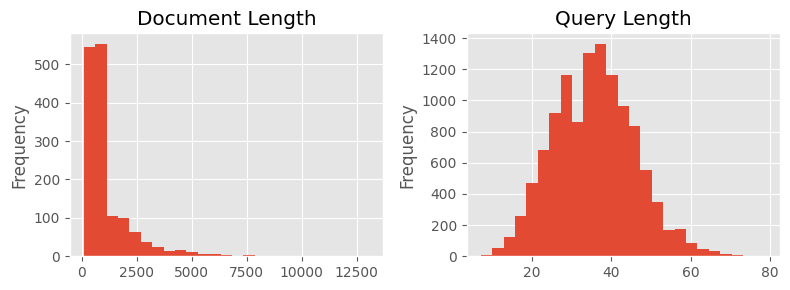

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

df_beir_corpus["text"].str.len().plot.hist(bins=25, ax=ax[0])
ax[0].set_title("Document Length")

df_beir_queries["text"].str.len().plot.hist(bins=25, ax=ax[1])
ax[1].set_title("Query Length")

fig.tight_layout()
plt.show()

In [20]:
df_beir_qrels = pd.read_csv("../data/dataset-new/cleaned/qrels.tsv", sep="\t")
print(df_beir_qrels.shape)

df_beir_qrels.head()

(11612, 3)


,query-id,corpus-id,score
0,99b78da2-54b4-4afa-b4c8-06df0dfb53d8,1bcfc529-9788-4f8b-a8e4-c2780922cb9e,1
1,42a37e80-e810-4813-a551-09dcbd471fa6,1bcfc529-9788-4f8b-a8e4-c2780922cb9e,1
2,5a0b9395-c28a-4c33-b5cc-5c502ee78790,1bcfc529-9788-4f8b-a8e4-c2780922cb9e,1
3,b821e85d-a6c3-4413-a0ba-d09ab1b72c2a,1bcfc529-9788-4f8b-a8e4-c2780922cb9e,1
4,37959229-85cc-432d-97e4-b437002efb17,1bcfc529-9788-4f8b-a8e4-c2780922cb9e,1


### Frequency Distribution

In [21]:
tokenizer = nltk.WhitespaceTokenizer()
tokens = [
    tokenizer.tokenize(s.lower())
    for s in df_beir_corpus["text"]
]

freq = nltk.FreqDist(itertools.chain(*tokens))
freq

FreqDist({'nu': 7282, 'ka': 3712, 'anu': 3475, 'di': 3424, 'jeung': 3269, 'ku': 3240, 'teu': 2659, 'dina': 2592, 'aya': 2091, 'atawa': 1819, ...})

In [24]:
freq_common = freq.most_common(10)
df_common = pd.Series([x[1] for x in freq_common], index=[x[0] for x in freq_common])
df_common

nu       7282
ka       3712
anu      3475
di       3424
jeung    3269
ku       3240
teu      2659
dina     2592
aya      2091
atawa    1819
dtype: int64

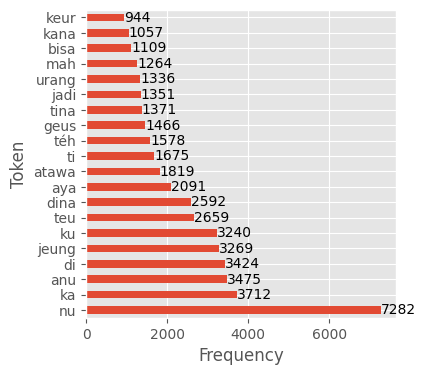

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

df_common.plot.barh(ax=ax)
ax.bar_label(ax.containers[0])
ax.set_xlabel("Frequency")
ax.set_ylabel("Token")

plt.show()